In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

engine = create_engine("postgresql+psycopg://localhost/props")

def q(sql):
    """Shortcut to run SQL and get a DataFrame."""
    return pd.read_sql(sql, engine)

In [2]:
q("""
SELECT sport_code, COUNT(*) AS games, MIN(game_date), MAX(game_date)
FROM games
GROUP BY sport_code
ORDER BY sport_code;
""")

,sport_code,games,min,max
0,mlb,7628,2023-03-30,2026-05-26
1,nba,2,2026-05-25,2026-05-26
2,nhl,2,2026-05-25,2026-05-26
3,wnba,5,2026-05-25,2026-05-27


In [3]:
q("""
SELECT sport_code, COUNT(*) AS player_games
FROM player_games pg
JOIN games g USING (game_id)
GROUP BY sport_code;
""")

,sport_code,player_games
0,mlb,52493


Total player-games: 37,316
count    37316.000000
mean         0.814664
std          0.866272
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: hits, dtype: float64


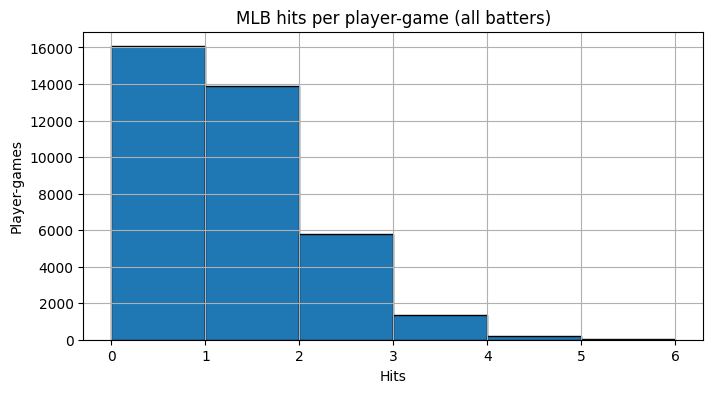

In [4]:
df = q("""
SELECT (pg.stats->>'hits')::int AS hits
FROM player_games pg
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int > 0;
""")
print(f"Total player-games: {len(df):,}")
print(df["hits"].describe())
df["hits"].hist(bins=range(0, 7), edgecolor='black', figsize=(8, 4))
plt.title("MLB hits per player-game (all batters)")
plt.xlabel("Hits")
plt.ylabel("Player-games")
plt.show()

In [5]:
df = q("""
SELECT p.full_name,
       COUNT(*) AS games,
       AVG((pg.stats->>'hits')::int) AS avg_hits,
       AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS over_15_rate
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'plate_appearances')::int >= 3
GROUP BY p.full_name
HAVING COUNT(*) >= 30
ORDER BY over_15_rate DESC
LIMIT 30;
""")
df

,full_name,games,avg_hits,over_15_rate
0,Yandy Díaz,109,1.284404,0.412844
1,Gabriel Moreno,46,1.173913,0.391304
2,Jeremy Peña,77,1.246753,0.389610
3,George Springer,117,1.230769,0.376068
4,Romy Gonzalez,67,1.134328,0.373134
5,Trevor Story,110,1.136364,0.372727
6,Ernie Clement,130,1.200000,0.369231
7,Vladimir Guerrero Jr.,132,1.189394,0.363636
8,Jonathan Aranda,69,1.202899,0.362319
9,Julio Rodríguez,134,1.104478,0.358209


In [6]:
q("""
SELECT p.full_name, pl.sport_code, pl.stat_type, pl.line_value
FROM prop_lines pl
JOIN players p ON p.player_id=pl.player_id
WHERE pl.sportsbook='prizepicks'
  AND pl.line_variant='standard'
  AND pl.sport_code='mlb'
ORDER BY pl.stat_type, p.full_name
LIMIT 30;
""")

,full_name,sport_code,stat_type,line_value
0,Aaron Civale,mlb,earned_runs_allowed,3.5
1,Aaron Civale,mlb,earned_runs_allowed,2.5
2,Braxton Ashcraft,mlb,earned_runs_allowed,3.5
3,Braxton Ashcraft,mlb,earned_runs_allowed,1.5
4,Braxton Ashcraft,mlb,earned_runs_allowed,0.5
5,Emmet Sheehan,mlb,earned_runs_allowed,3.5
6,Emmet Sheehan,mlb,earned_runs_allowed,0.5
7,Emmet Sheehan,mlb,earned_runs_allowed,1.5
8,Joe Ryan,mlb,earned_runs_allowed,2.5
9,Joe Ryan,mlb,earned_runs_allowed,3.5


In [7]:
df = q("""
WITH player_history AS (
    SELECT p.player_id, p.full_name,
           AVG((pg.stats->>'hits')::int) AS avg_hits,
           AVG(CASE WHEN (pg.stats->>'hits')::int >= 2 THEN 1.0 ELSE 0.0 END) AS hist_over_15,
           COUNT(*) AS sample
    FROM player_games pg
    JOIN players p USING (player_id)
    JOIN games g USING (game_id)
    WHERE g.sport_code='mlb'
      AND (pg.stats->>'plate_appearances')::int >= 3
    GROUP BY p.player_id, p.full_name
    HAVING COUNT(*) >= 30
),
current_lines AS (
    SELECT p.player_id, AVG(pl.line_value) AS pp_line
    FROM prop_lines pl
    JOIN players p ON p.player_id=pl.player_id
    WHERE pl.sportsbook='prizepicks'
      AND pl.line_variant='standard'
      AND pl.stat_type='hits'
      AND pl.sport_code='mlb'
    GROUP BY p.player_id
)
SELECT ph.full_name, ph.avg_hits, ph.hist_over_15, ph.sample, cl.pp_line
FROM player_history ph
JOIN current_lines cl USING (player_id)
ORDER BY cl.pp_line DESC, ph.hist_over_15 DESC
LIMIT 50;
""")
df

,full_name,avg_hits,hist_over_15,sample,pp_line
0,Julio Rodríguez,1.095588,0.352941,136,1.5
1,Josh Naylor,1.110169,0.288136,118,1.5
2,J.P. Crawford,0.953846,0.284615,130,1.5
3,Isaac Collins,0.893617,0.244681,94,1.5
4,Victor Caratini,0.918919,0.243243,74,1.5
5,Andrew Benintendi,0.908163,0.234694,98,1.5
6,Kyle Karros,0.720000,0.180000,50,1.5
7,Kyle Isbel,0.800000,0.175000,80,1.5
8,Jac Caglianone,0.602941,0.117647,68,1.5
9,Victor Scott II,0.564706,0.105882,85,1.5


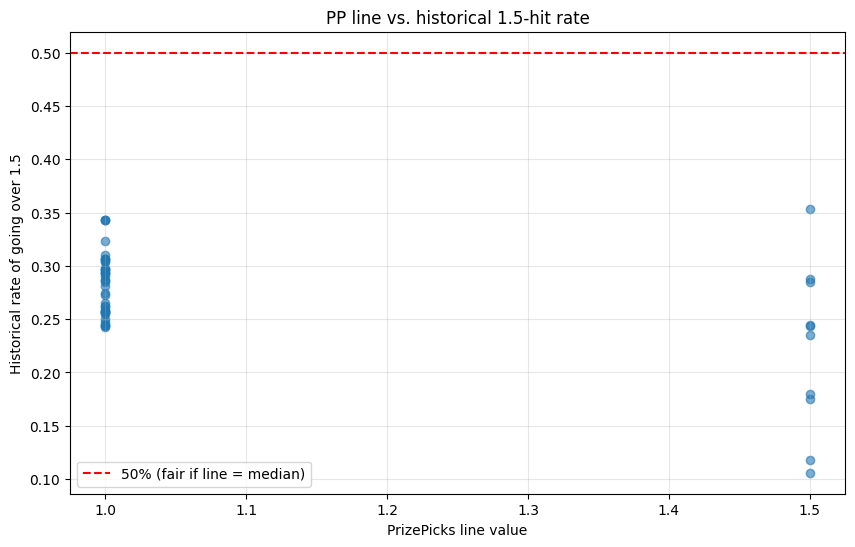

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["pp_line"], df["hist_over_15"], alpha=0.6)
plt.axhline(0.5, color='red', linestyle='--', label='50% (fair if line = median)')
plt.xlabel("PrizePicks line value")
plt.ylabel("Historical rate of going over 1.5")
plt.title("PP line vs. historical 1.5-hit rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
df_k = q("""
SELECT p.full_name,
       COUNT(*) AS starts,
       AVG((pg.stats->>'strikeouts_pitcher')::int) AS avg_k,
       AVG((pg.stats->>'outs_recorded')::int / 3.0) AS avg_ip
FROM player_games pg
JOIN players p USING (player_id)
JOIN games g USING (game_id)
WHERE g.sport_code='mlb'
  AND (pg.stats->>'batters_faced')::int >= 15
GROUP BY p.full_name
HAVING COUNT(*) >= 15
ORDER BY avg_k DESC
LIMIT 25;
""")
df_k

,full_name,starts,avg_k,avg_ip
0,Tarik Skubal,30,8.400000,6.411111
1,Chris Sale,19,8.263158,6.298246
2,Garrett Crochet,29,8.206897,6.448276
3,Zack Wheeler,23,8.043478,6.333333
4,Cristopher Sánchez,32,6.968750,6.614583
5,Dylan Cease,32,6.937500,5.250000
6,Jacob Misiorowski,17,6.823529,5.156863
7,Hunter Brown,27,6.814815,5.975309
8,Yoshinobu Yamamoto,33,6.787879,6.242424
9,Paul Skenes,31,6.741935,5.849462
